In [1]:
import os, math, scipy, skbio
import numpy as np
import pandas as pd
from skbio.diversity import beta_diversity
from skbio.stats.ordination import pcoa
import seaborn as sns
import matplotlib as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
import os
print("Working directory:", os.getcwd())
print("Conda environment:", os.environ.get('CONDA_DEFAULT_ENV'))

Working directory: /shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/jupyter
Conda environment: wnw


In [3]:
metadata = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_metadata.tsv')

In [4]:
metadata

,study_name,sample_id,subject_id,body_site,antibiotics_current_use,study_condition,disease,age,age_category,gender,...,non_westernized,sequencing_platform,PMID,number_reads,number_bases,minimum_read_length,median_read_length,NCBI_accession,curator,DNA_extraction_kit
0,NielsenHB_2014,O2_UC49_0,O2_UC49,stool,NaN,control,healthy,22.0,adult,female,...,no,IlluminaHiSeq,24997787.0,60584637.0,4.099972e+09,30.0,70.0,ERR210493;ERR210492;ERR209641;ERR209640,Paolo_Manghi,NaN
1,NielsenHB_2014,O2_UC49_2,O2_UC49,stool,NaN,control,healthy,22.0,adult,female,...,no,IlluminaHiSeq,24997787.0,56508214.0,3.775477e+09,30.0,70.0,ERR210495;ERR210494;ERR209643;ERR209642,Paolo_Manghi,NaN
2,NielsenHB_2014,O2_UC50_0,O2_UC50,stool,NaN,control,healthy,24.0,adult,male,...,no,IlluminaHiSeq,24997787.0,65105855.0,4.392995e+09,30.0,71.0,ERR210497;ERR210496;ERR209645;ERR209644,Paolo_Manghi,NaN
3,NielsenHB_2014,O2_UC50_2,O2_UC50,stool,NaN,control,healthy,24.0,adult,male,...,no,IlluminaHiSeq,24997787.0,53260679.0,3.596382e+09,30.0,70.0,ERR210500;ERR209648,Paolo_Manghi,NaN
4,NielsenHB_2014,O2_UC51_0,O2_UC51,stool,NaN,control,healthy,32.0,adult,female,...,no,IlluminaHiSeq,24997787.0,57486896.0,3.923766e+09,30.0,72.0,ERR210502;ERR210501;ERR209650;ERR209649,Paolo_Manghi,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12865,BorryM_2020,SAMEA6415059,SAMEA6415059,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12866,BorryM_2020,ERR3761407,ERR3761407,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12867,BorryM_2020,ERR3761411,ERR3761411,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12868,HaganRW_2019,Zape5,Zape5,stool,NaN,control,healthy,NaN,NaN,NaN,...,ancient,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
abundances = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_profiles.tsv')

In [6]:
abundances

,Unnamed: 0,MMRS62666492ST-27-0-0,MMRS51737257ST-27-0-0,MMRS38861560ST-27-0-0,MMRS95674036ST-27-0-0,MMRS67096717ST-27-0-0,MMRS84085284ST-27-0-0,MMRS51307502ST-27-0-0,MMRS17963147ST-27-0-0,MMRS39582183ST-27-0-0,...,SID15785561_SF07,SID19401504_SF05,SID20269046_SF08,SID50492523_SF07,SID10502288_SF08,SID72242320_SF07,SID30920067_SF07,SID11486372_SF08,SID16913125_SF05,SID16853657_SF05
0,k__Bacteria,99.93463,99.18388,100.00000,100.00000,100.00000,100.00000,97.99128,99.92570,93.18519,...,100.00000,100.00000,99.20735,100.00000,99.62772,99.57517,99.92819,99.93030,99.53060,100.00000
1,k__Archaea,0.06537,0.81612,0.00000,0.00000,0.00000,0.00000,2.00872,0.07430,6.81481,...,0.00000,0.00000,0.79265,0.00000,0.37228,0.42483,0.07181,0.06970,0.46940,0.00000
2,k__Bacteria|p__Firmicutes,69.66820,58.11043,69.86201,28.13507,54.76472,48.93404,81.31657,53.89673,70.39620,...,62.99205,57.98725,77.37153,56.84940,62.01985,70.64182,57.19654,64.96287,72.69495,56.00511
3,k__Bacteria|p__Bacteroidetes,28.66924,37.02095,28.10208,66.97080,20.40542,48.32282,10.73218,42.41865,19.37239,...,35.22573,38.97574,16.54528,35.27852,27.46251,21.14656,39.11211,20.96019,17.53030,37.48840
4,k__Bacteria|p__Proteobacteria,0.67858,1.44754,0.66079,2.82776,0.67835,0.02112,3.02764,2.76147,1.31107,...,0.49921,0.86482,0.72299,3.39898,3.28930,2.96303,1.12058,11.84127,2.04371,0.62305
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11524,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
11525,k__Bacteria|p__Bacteroidetes|c__Bacteroidia|o_...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
11526,k__Bacteria|p__Bacteroidetes|c__CFGB570|o__OFG...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
11527,k__Bacteria|p__Bacteroidetes|c__CFGB570|o__OFG...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [7]:
abundances.index = abundances['Unnamed: 0']
abundances = abundances.drop('Unnamed: 0',1)

/tmp/ipykernel_710623/1875833929.py:2: FutureWarning: In a future version of pandas all arguments of DataFrame.drop except for the argument 'labels' will be keyword-only.
  abundances = abundances.drop('Unnamed: 0',1)


In [8]:
keep = list()
for x in abundances.index.tolist():
    keep.append('t__' in x)
sgb_abundances = abundances.loc[keep]

In [9]:
adults_metadata = metadata[metadata['age'] != pd.NA]
adults_metadata = adults_metadata[adults_metadata['age'] != np.nan]
adults_metadata = adults_metadata[adults_metadata['age'].notna()]
adults_metadata = adults_metadata[adults_metadata['age'] != '1.083.333.333']
adults_metadata['age'] = adults_metadata['age'].astype(float)
adults_metadata = adults_metadata[adults_metadata['age'] > 16]
adults_metadata = adults_metadata[adults_metadata['study_name'] != 'HanniganGD_2017']
adults_metadata.index = adults_metadata['sample_id']

In [10]:
len(adults_metadata[adults_metadata['non_westernized'] == 'yes']) + len(adults_metadata[adults_metadata['non_westernized'] == 'no'])

6863

In [11]:
adults_metadata.study_name.unique()

array(['NielsenHB_2014', 'ThomasAM_2019_a', 'WampachL_2018',
       'RaymondF_2016', 'JieZ_2017', 'QinJ_2012', 'Obregon-TitoAJ_2015',
       'HMP_2019_ibdmdb', 'CM_ethiopia', 'SankaranarayananK_2015',
       'SmitsSA_2017', 'FengQ_2015', 'YachidaS_2019',
       'Heitz-BuschartA_2016', 'BritoIL_2016', 'RubelMA_2020',
       'KeohaneDM_2020', 'WirbelJ_2018', 'CM_madagascar', 'YuJ_2015',
       'AsnicarF_2021', 'CM_caritro', 'LifeLinesDeep_2016',
       'KarlssonFH_2013', 'LokmerA_2019', 'HMP_2012', 'HMP_2019_t2d',
       'SchirmerM_2016', 'ThomasAM_2019_c', 'RampelliS_2015',
       'DhakanDB_2019', 'ChuDM_2017', 'XieH_2016', 'YeZ_2018',
       'GuptaA_2019', 'BengtssonPalmeJ_2015', 'CosteaPI_2017',
       'IjazUZ_2017', 'VogtmannE_2016', 'HansenLBS_2018', 'QinN_2014',
       'NagySzakalD_2017', 'ZellerG_2014', 'ThomasAM_2019_b', 'ZhuF_2020',
       'KaurK_2020', 'PehrssonE_2016', 'ShaoY_2019', 'DeFilippisF_2019',
       'CM_tanzania_TB_DAR', 'CM_argentina', 'CM_colombia', 'CM_ghana2',
  

In [12]:
ancient_metadata = metadata[metadata['non_westernized'] == 'ancient']
ancient_metadata.index = ancient_metadata['sample_id']
ancient_adult_metadata = ancient_metadata.append(adults_metadata)

/tmp/ipykernel_710623/4245977551.py:3: FutureWarning: The frame.append method is deprecated and will be removed from pandas in a future version. Use pandas.concat instead.
  ancient_adult_metadata = ancient_metadata.append(adults_metadata)


In [13]:
sgb_abundances.index = [x.split('|')[-2][3:].replace('_',' ') + ' (' + x.split('|')[-1][3:] +')' for x in sgb_abundances.index.tolist()]

In [14]:
sgb_abundances

,MMRS62666492ST-27-0-0,MMRS51737257ST-27-0-0,MMRS38861560ST-27-0-0,MMRS95674036ST-27-0-0,MMRS67096717ST-27-0-0,MMRS84085284ST-27-0-0,MMRS51307502ST-27-0-0,MMRS17963147ST-27-0-0,MMRS39582183ST-27-0-0,MMRS35808664ST-27-0-0,...,SID15785561_SF07,SID19401504_SF05,SID20269046_SF08,SID50492523_SF07,SID10502288_SF08,SID72242320_SF07,SID30920067_SF07,SID11486372_SF08,SID16913125_SF05,SID16853657_SF05
Prevotella copri clade A (SGB1626),11.54777,0.00000,0.00561,0.0,0.00000,9.73808,0.00234,0.0008,5.30270,28.78837,...,0.0,0.0,1.29064,0.00000,0.00000,0.00000,24.37621,0.0,0.00000,0.0
Ruminococcus sp NSJ 71 (SGB4290),6.73408,0.67540,3.45553,0.0,0.00133,0.00000,0.15589,0.0000,0.00000,0.38613,...,0.0,0.0,2.76623,0.00000,0.00000,0.00000,0.00000,0.0,4.52322,0.0
Coprococcus eutactus (SGB5117),5.34157,0.00041,1.53598,0.0,0.00000,0.00000,0.00000,0.0000,0.75849,0.00000,...,0.0,0.0,0.61609,0.00000,0.00000,1.05172,0.94246,0.0,0.00000,0.0
GGB3226 SGB4260 (SGB4260),3.17368,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0
Ruminococcaceae unclassified SGB15234 (SGB15234),2.98767,0.00000,0.70183,0.0,0.00000,0.00000,0.92188,0.0000,0.09317,0.00000,...,0.0,0.0,0.16389,0.22321,2.28257,0.88860,0.00000,0.0,2.07058,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GGB28250 SGB40793 (SGB40793),0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0
GGB27924 SGB40362 (SGB40362),0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0
Propionibacteriaceae bacterium NML 150081 (SGB15922),0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0
GGB27883 SGB40317 (SGB40317),0.00000,0.00000,0.00000,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,...,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0


In [18]:
adults_abundances = sgb_abundances[adults_metadata['sample_id']]
ancient_adult_abundances = sgb_abundances[ancient_adult_metadata['sample_id']]
adults_abundances

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,C16-20615-TZ,C16-20616-TZ,C16-20617-TZ,C16-20625-TZ,C16-20626-TZ,C16-20627-TZ,C16-20645-TZ,C16-20646-TZ,C16-20647-TZ,C16-20664-TZ
Prevotella copri clade A (SGB1626),0.0,0.00000,0.99226,0.00000,0.00000,0.00000,2.95526,0.0,0.00000,0.0,...,4.67726,5.30976,20.47193,12.11931,5.17480,8.29545,7.22606,6.61441,0.68483,0.49648
Ruminococcus sp NSJ 71 (SGB4290),0.0,0.00000,7.81511,5.32192,0.00000,0.00000,7.74245,0.0,0.00000,0.0,...,0.23187,0.21361,0.00000,0.05948,0.00000,2.73756,0.04019,0.01647,0.00000,0.00000
Coprococcus eutactus (SGB5117),0.0,0.00000,0.05737,0.00000,4.03200,2.26458,0.16282,0.0,0.00000,0.0,...,0.00000,0.00000,0.19342,1.06580,0.07770,0.00000,0.00293,0.03258,0.21350,1.87686
GGB3226 SGB4260 (SGB4260),0.0,0.00000,0.00000,0.00000,0.72760,1.39484,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.01816,0.00000,0.07773,0.00000
Ruminococcaceae unclassified SGB15234 (SGB15234),0.0,0.48968,0.14505,0.00000,0.04497,0.06637,0.18059,0.0,0.01218,0.0,...,0.11756,0.14315,0.02202,0.00128,0.01109,0.03210,0.08475,0.06938,0.01028,0.04632
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GGB28250 SGB40793 (SGB40793),0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
GGB27924 SGB40362 (SGB40362),0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
Propionibacteriaceae bacterium NML 150081 (SGB15922),0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
GGB27883 SGB40317 (SGB40317),0.0,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.0,0.00000,0.0,...,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [16]:
adults_abundances = adults_abundances.drop(adults_abundances.loc[adults_abundances.sum(axis=1) == 0].index.tolist())
adults_abundances = adults_abundances.transpose()
adults_abundances = adults_abundances.drop(adults_abundances.loc[adults_abundances.sum(axis=1) == 0].index.tolist())

In [17]:
ancient_adult_abundances = ancient_adult_abundances.drop(ancient_adult_abundances.loc[ancient_adult_abundances.sum(axis=1) == 0].index.tolist())
ancient_adult_abundances = ancient_adult_abundances.transpose()
ancient_adult_abundances = ancient_adult_abundances.drop(ancient_adult_abundances.loc[ancient_adult_abundances.sum(axis=1) == 0].index.tolist())

##  Beta diversity

In [19]:
def confidence_ellipse(x, y, ax, n_std=2.0, facecolor='none', **kwargs):
    """
    Create a plot of the covariance confidence ellipse of *x* and *y*.

    Parameters
    ----------
    x, y : array-like, shape (n, )
        Input data.

    ax : matplotlib.axes.Axes
        The axes object to draw the ellipse into.

    n_std : float
        The number of standard deviations to determine the ellipse's radiuses.

    **kwargs
        Forwarded to `~matplotlib.patches.Ellipse`

    Returns
    -------
    matplotlib.patches.Ellipse
    """
    if x.size != y.size:
        raise ValueError("x and y must be the same size")

    cov = np.cov(x, y)
    pearson = cov[0, 1]/np.sqrt(cov[0, 0] * cov[1, 1])
    # Using a special case to obtain the eigenvalues of this
    # two-dimensional dataset.
    ell_radius_x = np.sqrt(1 + pearson)
    ell_radius_y = np.sqrt(1 - pearson)
    ellipse = Ellipse((0, 0), width=ell_radius_x * 2, height=ell_radius_y * 2,
                      facecolor=facecolor, **kwargs)

    # Calculating the standard deviation of x from
    # the squareroot of the variance and multiplying
    # with the given number of standard deviations.
    scale_x = np.sqrt(cov[0, 0]) * n_std
    mean_x = np.mean(x)

    # calculating the standard deviation of y ...
    scale_y = np.sqrt(cov[1, 1]) * n_std
    mean_y = np.mean(y)

    transf = transforms.Affine2D() \
        .rotate_deg(45) \
        .scale(scale_x, scale_y) \
        .translate(mean_x, mean_y)

    ellipse.set_transform(transf + ax.transData)
    return ax.add_patch(ellipse)

In [20]:
def arcsinsqrt(x):
    return np.arcsin(math.sqrt((x) / 100))

In [21]:
adults_abundances_transf = adults_abundances.applymap(arcsinsqrt)

In [19]:
adults_abundances_transf.T.to_csv(' ', sep='\t')

In [23]:
adults_abundances_transf.T

,Prevotella copri clade A (SGB1626),Ruminococcus sp NSJ 71 (SGB4290),Coprococcus eutactus (SGB5117),GGB3226 SGB4260 (SGB4260),Ruminococcaceae unclassified SGB15234 (SGB15234),Phocaeicola vulgatus (SGB1814),Alistipes putredinis (SGB2318),Dialister invisus (SGB5825_group),Faecalibacterium prausnitzii (SGB15332_group),Bacilli unclassified SGB6571 (SGB6571),...,Kerstersia gyiorum (SGB13160),Clostridium mediterraneense (SGB21135),GGB28645 SGB41267 (SGB41267),GGB27885 SGB40319 (SGB40319),Methanomassiliicoccus luminyensis (SGB33442),GGB28250 SGB40793 (SGB40793),GGB27924 SGB40362 (SGB40362),Propionibacteriaceae bacterium NML 150081 (SGB15922),GGB27883 SGB40317 (SGB40317),GGB1201 SGB1566 (SGB1566)
O2_UC49_0,0.000000,0.000000,0.000000,0.000000,0.000000,0.296977,0.149068,0.282154,0.026240,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC49_2,0.000000,0.000000,0.000000,0.000000,0.070034,0.237674,0.124572,0.097414,0.051180,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC50_0,0.099778,0.283331,0.023954,0.000000,0.038095,0.206033,0.111583,0.000000,0.079617,0.009773,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC50_2,0.000000,0.232790,0.000000,0.000000,0.000000,0.236472,0.143576,0.000000,0.106821,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC51_0,0.000000,0.000000,0.202173,0.085403,0.021208,0.014043,0.165522,0.004243,0.031310,0.020220,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C16-20627-TZ,0.292157,0.166220,0.000000,0.000000,0.017917,0.280855,0.032482,0.000000,0.075111,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C16-20645-TZ,0.272161,0.020049,0.005413,0.013476,0.029116,0.000000,0.000000,0.000000,0.073946,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C16-20646-TZ,0.260108,0.012834,0.018051,0.000000,0.026343,0.020873,0.008729,0.000000,0.059258,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C16-20647-TZ,0.082849,0.000000,0.046223,0.027884,0.010139,0.012566,0.006863,0.000000,0.074480,0.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
bray_curtis_adults = beta_diversity(metric="braycurtis", counts=adults_abundances_transf.values, ids=adults_abundances_transf.index)

In [22]:
adults_prevalences = adults_abundances.copy()
adults_prevalences[adults_prevalences > 0] = 1

In [23]:
ancient_adults_prevalences = ancient_adult_abundances.copy()
ancient_adults_prevalences[ancient_adults_prevalences > 0] = 1
#ancient_adults_prevalences[adults_prevalences < 0.001] = 0
ancient_adults_prevalences = ancient_adults_prevalences.astype(int)
ancient_adults_prevalences

,Prevotella copri clade A (SGB1626),Ruminococcus sp NSJ 71 (SGB4290),Coprococcus eutactus (SGB5117),GGB3226 SGB4260 (SGB4260),Ruminococcaceae unclassified SGB15234 (SGB15234),Phocaeicola vulgatus (SGB1814),Alistipes putredinis (SGB2318),Dialister invisus (SGB5825_group),Faecalibacterium prausnitzii (SGB15332_group),Bacilli unclassified SGB6571 (SGB6571),...,Aquamicrobium defluvii (SGB32233),Jeotgalibaca porci (SGB64172),Paracoccus solventivorans (SGB10725),Paracandidimonas soli (SGB32666),Paracoccus alkenifer (SGB10726),Arcobacter trophiarum (SGB28493),Aquamicrobium lusatiense (SGB89540),Proteiniborus ethanoligenes (SGB8530),Propioniciclava sp MC1595 (SGB87720),Bosea sp WAO (SGB11414)
2611_merged,1,1,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2612_Plus,1,0,1,0,0,1,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2604_merged,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2610_merged,1,1,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2180a_merged,1,0,1,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C16-20627-TZ,1,1,0,0,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
C16-20645-TZ,1,1,1,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
C16-20646-TZ,1,1,1,0,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
C16-20647-TZ,1,0,1,1,1,1,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [24]:
jaccard_adults = beta_diversity(metric="jaccard", counts=adults_prevalences.values, ids=adults_prevalences.index)

In [45]:
p = skbio.stats.distance.permanova(jaccard_adults, adults_metadata.loc[adults_prevalences.index, 'non_westernized'], permutations=999)
p

method name                PERMANOVA
test statistic name         pseudo-F
sample size                     6861
number of groups                   2
test statistic            357.020808
p-value                        0.001
number of permutations           999
Name: PERMANOVA results, dtype: object

In [46]:
r2 = 1 - 1 / (1 + p[4] * p[3] / (p[2] - p[3] - 1))
r2

0.09429974790313556

In [25]:
jaccard_ancient_adults = beta_diversity(metric="jaccard", counts=ancient_adults_prevalences.values, ids=ancient_adults_prevalences.index)

In [26]:
variables = ancient_adult_metadata.loc[ancient_adults_prevalences.index, 'non_westernized'].tolist()
colors = list()
size1 = list()
size2 = list()
styles = list()
for x in variables:
    if x == 'no':
        colors.append('#397797')
        size1.append(15)
        size2.append(0)
        styles.append('o')
    elif x == 'yes':
        colors.append('#d5d53e')
        size1.append(15)
        size2.append(0)
        styles.append('o')
    else:
        colors.append('#f27400')
        size1.append(0)
        size2.append(150)
        styles.append('*')

In [22]:
variables = adults_metadata.loc[adults_abundances_transf.index, 'non_westernized'].tolist()
colors = list()
size1 = list()
size2 = list()
styles = list()
for x in variables:
    if x == 'no':
        colors.append('#397797')
        size1.append(15)
        size2.append(0)
        styles.append('o')
    elif x == 'yes':
        colors.append('#d5d53e')
        size1.append(15)
        size2.append(0)
        styles.append('o')
    else:
        colors.append('#f27400')
        size1.append(0)
        size2.append(150)
        styles.append('*')

In [27]:
bc_pcoa = pcoa(bray_curtis_adults)

/shares/CIBIO-Storage/CM/scratch/prebiomics/tools/anaconda3/envs/jupyter/lib/python3.8/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:143: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -1.968266477508815 and the largest is 197.1616261272308.
  warn(


In [28]:
jcc_pcoa = pcoa(jaccard_adults)

/shares/CIBIO-Storage/CM/scratch/prebiomics/tools/anaconda3/envs/jupyter/lib/python3.8/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:143: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -0.17216214975369323 and the largest is 195.41153192067904.
  warn(


In [29]:
jcc_pcoa = pcoa(jaccard_ancient_adults)

/shares/CIBIO-Storage/CM/scratch/prebiomics/tools/anaconda3/envs/jupyter/lib/python3.8/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:143: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -0.17253120760117094 and the largest is 196.78044530182228.
  warn(


In [30]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [5,5]
sns.scatterplot(bc_pcoa.samples['PC1'], -bc_pcoa.samples['PC2'], alpha=0.75, s=size1, c=colors, style=styles, legend=False)
plt.pyplot.xlabel("PCoA1")
plt.pyplot.ylabel("PCoA2")
# plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/brayc_west.svg')

/shares/CIBIO-Storage/CM/scratch/prebiomics/tools/anaconda3/envs/jupyter/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


ValueError: array length 6888 does not match index length 6861

/shares/CIBIO-Storage/CM/scratch/prebiomics/tools/anaconda3/envs/jupyter/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(
/shares/CIBIO-Storage/CM/scratch/prebiomics/tools/anaconda3/envs/jupyter/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


Text(0, 0.5, 'PCoA2 (6.31%)')

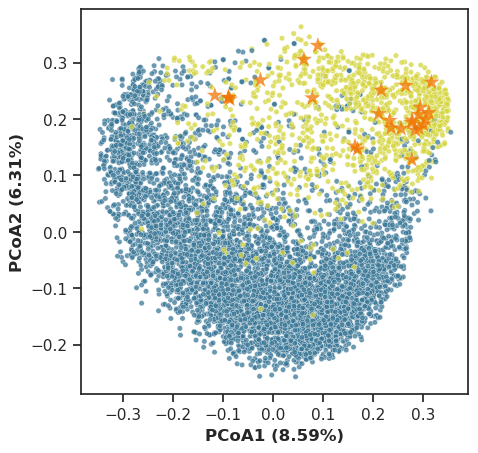

In [34]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [5,5]
sns.scatterplot(-jcc_pcoa.samples['PC1'], jcc_pcoa.samples['PC2'], alpha=0.75, s=size1, c=colors,  markers=['*','o'], style=styles, legend=False)
sns.scatterplot(-jcc_pcoa.samples['PC1'], jcc_pcoa.samples['PC2'], alpha=0.75, s=size2, c=colors,  markers=['*','o'], style=styles, legend=False)
var1 = round(100 * jcc_pcoa.eigvals['PC1'] / jcc_pcoa.eigvals.sum() ,2)
var2 = round(100 * jcc_pcoa.eigvals['PC2'] / jcc_pcoa.eigvals.sum() ,2)
plt.pyplot.xlabel("PCoA1 ({}%)".format(var1), fontdict={'weight': 'bold'})
plt.pyplot.ylabel("PCoA2 ({}%)".format(var2), fontdict={'weight': 'bold'})
# plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/jaccard_west.svg')

In [38]:
hdi = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_hdi.tsv')

In [39]:
hdi.index = hdi['Country code']
country = adults_metadata['country'].tolist()
hdi19 = hdi.loc[country]['HDI 2019']
hdi19.index = adults_metadata['sample_id']

In [41]:
p = skbio.stats.distance.permanova(jaccard_adults, hdi19[adults_prevalences.index], permutations=999)
p

method name               PERMANOVA
test statistic name        pseudo-F
sample size                    6861
number of groups                 29
test statistic            42.723061
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object

In [44]:
r2 = 1 - 1 / (1 + p[4] * p[3] / (p[2] - p[3] - 1))
r2

0.1535283233070701

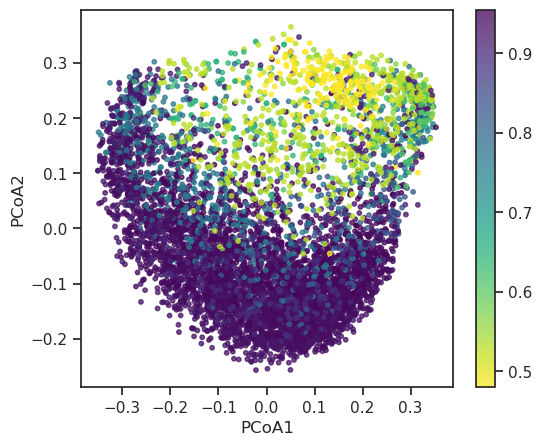

In [101]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [6,5]
plt.pyplot.scatter(jcc_pcoa.samples['PC1'] , jcc_pcoa.samples['PC2'], alpha=0.75, s=10, c= hdi19[adults_prevalences.index], cmap="viridis_r")
plt.pyplot.xlabel("PCoA1")
plt.pyplot.ylabel("PCoA2")
plt.pyplot.colorbar()
# plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/jaccard_hdi.svg')

In [115]:
wuni = pd.read_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/diversity_analysis/nw_relab_asinsqrt_weighted-unifrac.tsv', sep = '\t')
wuni

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,C16-20615-TZ,C16-20616-TZ,C16-20617-TZ,C16-20625-TZ,C16-20626-TZ,C16-20627-TZ,C16-20645-TZ,C16-20646-TZ,C16-20647-TZ,C16-20664-TZ
O2_UC49_0,0.000000,0.269585,0.292764,0.255923,0.288212,0.302135,0.338127,0.200619,0.177647,0.188379,...,0.400897,0.405185,0.249825,0.286945,0.308130,0.290399,0.379440,0.316890,0.380143,0.377777
O2_UC49_2,0.269585,0.000000,0.165380,0.174588,0.162438,0.180893,0.215873,0.255469,0.240861,0.225274,...,0.298003,0.305001,0.286014,0.350099,0.353032,0.212735,0.334742,0.304359,0.300319,0.286236
O2_UC50_0,0.292764,0.165380,0.000000,0.130724,0.161488,0.141563,0.141514,0.226686,0.226663,0.210267,...,0.233987,0.238456,0.273939,0.334603,0.340585,0.197749,0.303639,0.289373,0.261517,0.241629
O2_UC50_2,0.255923,0.174588,0.130724,0.000000,0.147415,0.151001,0.254727,0.174356,0.174997,0.167175,...,0.285066,0.290924,0.259587,0.330147,0.361617,0.191694,0.343971,0.298098,0.288908,0.242274
O2_UC51_0,0.288212,0.162438,0.161488,0.147415,0.000000,0.097380,0.236340,0.221068,0.213572,0.199497,...,0.284991,0.289260,0.288028,0.347423,0.370188,0.222802,0.352754,0.330569,0.298812,0.251360
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C16-20627-TZ,0.290399,0.212735,0.197749,0.191694,0.222802,0.204116,0.255682,0.250248,0.224866,0.219011,...,0.234264,0.242638,0.220737,0.272575,0.286940,0.000000,0.264153,0.220834,0.240370,0.216291
C16-20645-TZ,0.379440,0.334742,0.303639,0.343971,0.352754,0.330644,0.299145,0.391810,0.345463,0.336813,...,0.234756,0.240913,0.246344,0.226366,0.217856,0.264153,0.000000,0.169907,0.161306,0.266119
C16-20646-TZ,0.316890,0.304359,0.289373,0.298098,0.330569,0.310378,0.318206,0.340637,0.292086,0.287727,...,0.253508,0.256920,0.171460,0.171508,0.180344,0.220834,0.169907,0.000000,0.179165,0.241880
C16-20647-TZ,0.380143,0.300319,0.261517,0.288908,0.298812,0.286450,0.290137,0.347284,0.347692,0.329354,...,0.217368,0.220804,0.245341,0.252287,0.254291,0.240370,0.161306,0.179165,0.000000,0.202117


In [129]:
skbio.stats.distance.permanova(skbio.stats.distance.DistanceMatrix(wuni), adults_metadata.loc[adults_prevalences.index, 'non_westernized'], permutations=999)

method name                PERMANOVA
test statistic name         pseudo-F
sample size                     6861
number of groups                   2
test statistic            383.736633
p-value                        0.001
number of permutations           999
Name: PERMANOVA results, dtype: object

In [118]:
wuni_pcoa = pcoa(wuni)

/shares/CIBIO-Storage/CM/cmstore/tools/anaconda3/envs/aitor_jupyter/lib/python3.8/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:143: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -3.244998279107895 and the largest is 135.15554881008205.
  warn(


/shares/CIBIO-Storage/CM/cmstore/tools/anaconda3/envs/aitor_jupyter/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


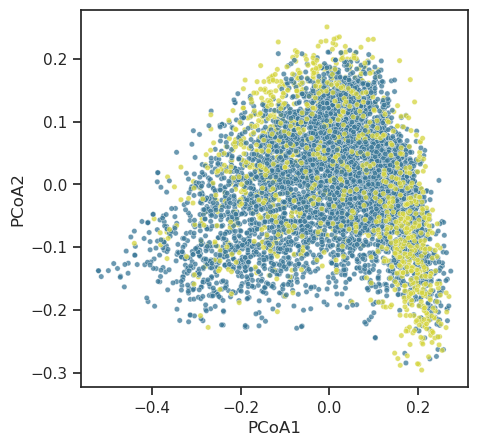

In [121]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [5,5]
sns.scatterplot(wuni_pcoa.samples['PC1'], -wuni_pcoa.samples['PC2'], alpha=0.75, s=size1, c=colors, style=styles, legend=False)
plt.pyplot.xlabel("PCoA1")
plt.pyplot.ylabel("PCoA2")
plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/wuni_west.svg')

In [116]:
uwuni = pd.read_csv('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/diversity_analysis/nw_relab_asinsqrt_unweighted-unifrac.tsv', sep = '\t')
uwuni

,O2_UC49_0,O2_UC49_2,O2_UC50_0,O2_UC50_2,O2_UC51_0,O2_UC51_2,O2_UC52_0,O2_UC53_0,O2_UC53_2,O2_UC54_0,...,C16-20615-TZ,C16-20616-TZ,C16-20617-TZ,C16-20625-TZ,C16-20626-TZ,C16-20627-TZ,C16-20645-TZ,C16-20646-TZ,C16-20647-TZ,C16-20664-TZ
O2_UC49_0,0.000000,0.544741,0.659262,0.539089,0.588927,0.617454,0.674887,0.458650,0.503118,0.497987,...,0.738702,0.740045,0.667470,0.727352,0.712745,0.630902,0.792581,0.745498,0.772887,0.735416
O2_UC49_2,0.544741,0.000000,0.436640,0.461917,0.442597,0.438564,0.519230,0.592880,0.573786,0.583837,...,0.669050,0.667640,0.667478,0.674806,0.695913,0.635472,0.728739,0.705080,0.713103,0.657345
O2_UC50_0,0.659262,0.436640,0.000000,0.366405,0.364927,0.348408,0.227639,0.611693,0.559023,0.573507,...,0.580182,0.583797,0.614061,0.617413,0.644433,0.547979,0.633409,0.616723,0.612411,0.559998
O2_UC50_2,0.539089,0.461917,0.366405,0.000000,0.402208,0.417381,0.528396,0.493454,0.447346,0.457400,...,0.667232,0.667458,0.634659,0.667628,0.700149,0.548974,0.720234,0.685306,0.690512,0.654706
O2_UC51_0,0.588927,0.442597,0.364927,0.402208,0.000000,0.146046,0.415314,0.542013,0.464039,0.496944,...,0.586892,0.591804,0.599521,0.606828,0.634797,0.529308,0.650503,0.630775,0.628411,0.575653
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C16-20627-TZ,0.630902,0.635472,0.547979,0.548974,0.529308,0.520255,0.559328,0.572306,0.564243,0.553446,...,0.520967,0.537426,0.475297,0.500522,0.528258,0.000000,0.573831,0.545802,0.525090,0.487472
C16-20645-TZ,0.792581,0.728739,0.633409,0.720234,0.650503,0.636098,0.645535,0.742184,0.732576,0.718243,...,0.404964,0.415530,0.507343,0.446838,0.477319,0.573831,0.000000,0.356055,0.308641,0.379211
C16-20646-TZ,0.745498,0.705080,0.616723,0.685306,0.630775,0.620623,0.619213,0.693188,0.693802,0.664922,...,0.389877,0.398400,0.456546,0.435231,0.428372,0.545802,0.356055,0.000000,0.301377,0.384330
C16-20647-TZ,0.772887,0.713103,0.612411,0.690512,0.628411,0.605720,0.610895,0.716730,0.716433,0.682951,...,0.388911,0.409817,0.478939,0.436157,0.453610,0.525090,0.308641,0.301377,0.000000,0.360523


In [130]:
skbio.stats.distance.permanova(skbio.stats.distance.DistanceMatrix(uwuni), adults_metadata.loc[adults_prevalences.index, 'non_westernized'], permutations=999)

method name                PERMANOVA
test statistic name         pseudo-F
sample size                     6861
number of groups                   2
test statistic            425.324139
p-value                        0.001
number of permutations           999
Name: PERMANOVA results, dtype: object

In [117]:
uwuni_pcoa = pcoa(uwuni)

/shares/CIBIO-Storage/CM/cmstore/tools/anaconda3/envs/aitor_jupyter/lib/python3.8/site-packages/skbio/stats/ordination/_principal_coordinate_analysis.py:143: RuntimeWarning: The result contains negative eigenvalues. Please compare their magnitude with the magnitude of some of the largest positive eigenvalues. If the negative ones are smaller, it's probably safe to ignore them, but if they are large in magnitude, the results won't be useful. See the Notes section for more details. The smallest eigenvalue is -0.31384280061956954 and the largest is 207.95574013254523.
  warn(


/shares/CIBIO-Storage/CM/cmstore/tools/anaconda3/envs/aitor_jupyter/lib/python3.8/site-packages/seaborn/_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


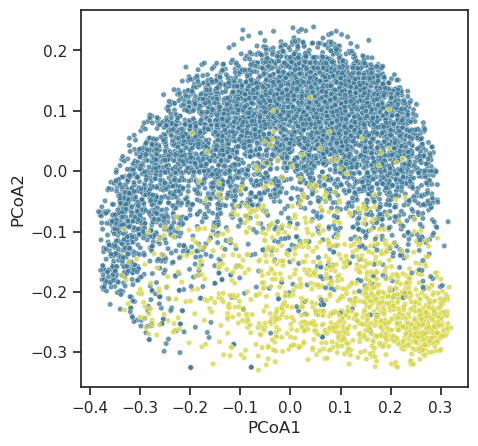

In [120]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [5,5]
sns.scatterplot(uwuni_pcoa.samples['PC1'], -uwuni_pcoa.samples['PC2'], alpha=0.75, s=size1, c=colors, style=styles, legend=False)
plt.pyplot.xlabel("PCoA1")
plt.pyplot.ylabel("PCoA2")
plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/uwuni_west.svg')

## Check rel.ab distributions

In [113]:
tmp = adults_abundances.loc[[x for x in sgb_richness.index.tolist() if sgb_richness.loc[x,'non_westernized'] == 'no']]
to_list = list()
for x in tmp.index.tolist():
    tmp_list = [y for y in tmp.loc[x] if y != 0]
    tmp_list.sort(reverse=True)
    i = 1
    for j in tmp_list:
        to_list.append([x, i, j, 'Westernized'])
        i+= 1
tmp = adults_abundances.loc[[x for x in sgb_richness.index.tolist() if sgb_richness.loc[x,'non_westernized'] == 'yes']]
for x in tmp.index.tolist():
    tmp_list = [y for y in tmp.loc[x] if y != 0]
    tmp_list.sort(reverse=True)
    i = 1
    for j in tmp_list:
        to_list.append([x, i, j, 'non-Westernized'])
        i+= 1
tmp_df = pd.DataFrame(to_list)
tmp_df.columns = ['sample', 'sgb', 'relab', 'lifestyle']

[(0.0, 100.0)]

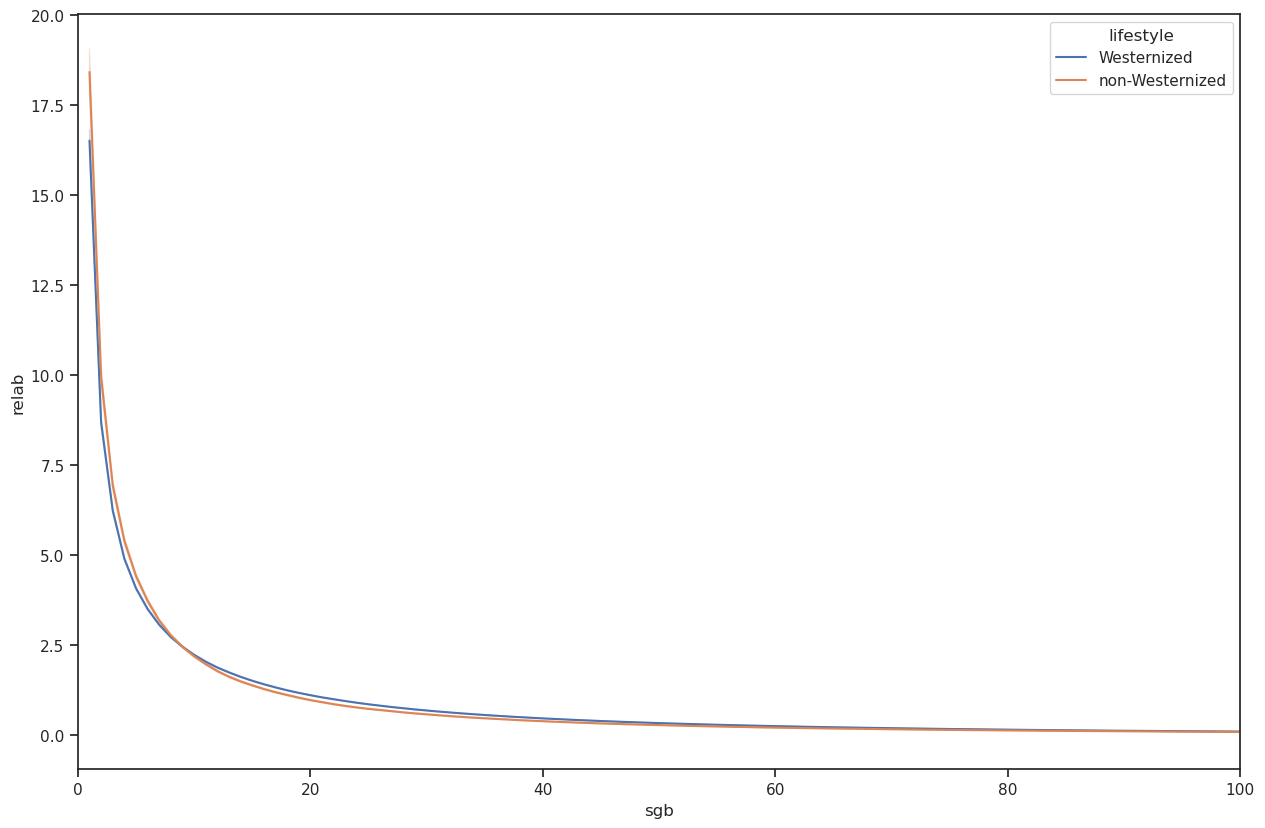

In [114]:
plt.rcParams['figure.figsize'] = [15,10]
g = sns.lineplot(data=tmp_df, x="sgb", y="relab", hue='lifestyle')
g.set(xlim=(0, 100))

In [111]:
tmp = adults_abundances.loc[[x for x in sgb_richness.index.tolist() if sgb_richness.loc[x,'non_westernized'] == 'no']]
to_list = list()
for x in tmp.index.tolist():
    tmp_list = [y for y in tmp.loc[x] if y != 0]
    tmp_list.sort(reverse=True)
    i = 1
    for j in tmp_list:
        to_list.append([x, i, math.log10(j), 'Westernized'])
        i+= 1
tmp = adults_abundances.loc[[x for x in sgb_richness.index.tolist() if sgb_richness.loc[x,'non_westernized'] == 'yes']]
for x in tmp.index.tolist():
    tmp_list = [y for y in tmp.loc[x] if y != 0]
    tmp_list.sort(reverse=True)
    i = 1
    for j in tmp_list:
        to_list.append([x, i, math.log10(j), 'non-Westernized'])
        i+= 1
tmp_df = pd.DataFrame(to_list)
tmp_df.columns = ['sample', 'sgb', 'relab', 'lifestyle']

[(0.0, 100.0)]

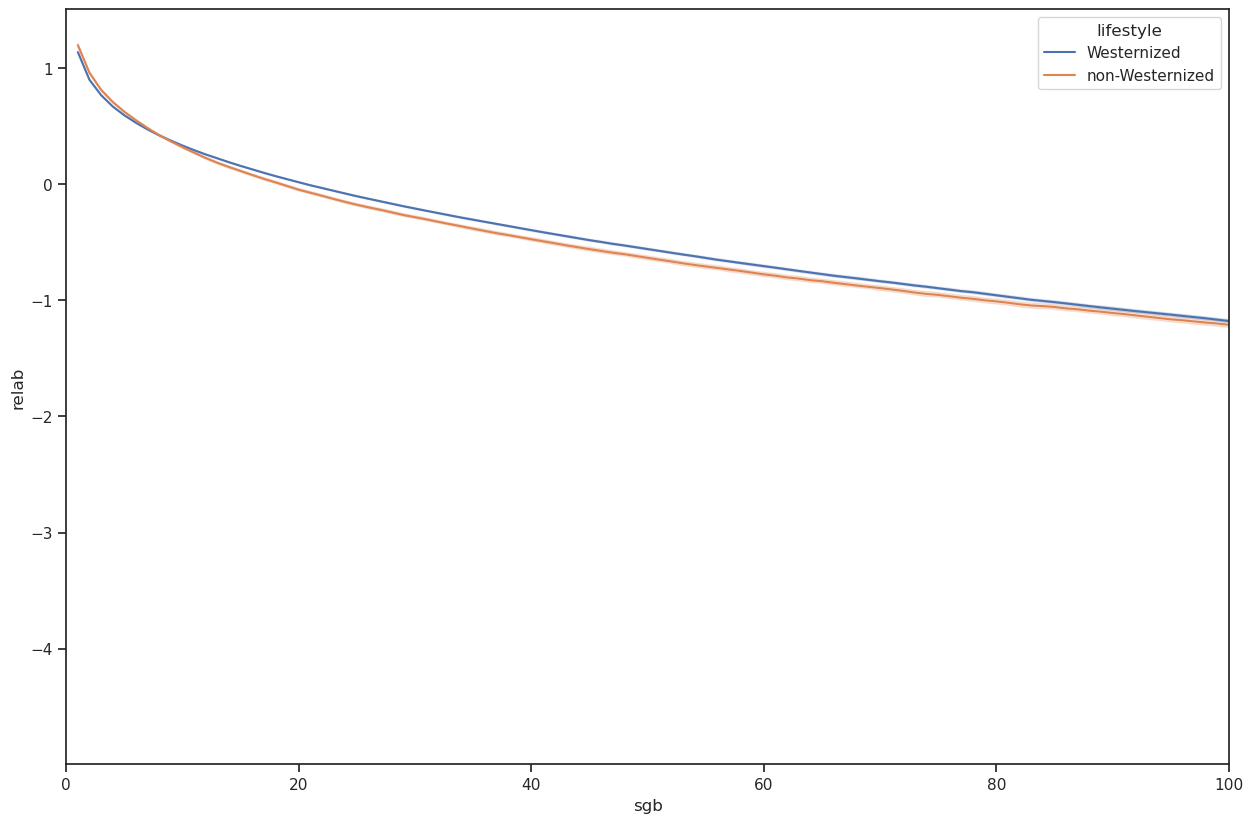

In [112]:
plt.rcParams['figure.figsize'] = [15,10]
g = sns.lineplot(data=tmp_df, x="sgb", y="relab", hue='lifestyle')
g.set(xlim=(0, 100))

## Check for entropy

In [45]:
import scipy.stats as sps

In [50]:
x = sps.entropy(adults_abundances.T)

In [51]:
x.shape

(6861,)

In [52]:
x

array([3.46467011, 4.09180433, 4.52940331, ..., 3.92222121, 4.19902884,
       4.46616516])

## Alpha diversity

In [54]:
adults_prevalences = adults_abundances.copy()
adults_prevalences[adults_prevalences > 0] = 1
sgb_richness = adults_prevalences.sum(axis=1)
sgb_richness = pd.DataFrame(sgb_richness)
sgb_richness.columns = ['richness']
sgb_richness['non_westernized'] = adults_metadata.loc[sgb_richness.index,'non_westernized']
sgb_richness['hdi'] = hdi19[sgb_richness.index]
sgb_richness['shannon2'] = x
# keep = list()
# for x in abundances.index.tolist():
#     keep.append('t__' in x)
sgb_formetrics = adults_abundances.copy()
for i in sgb_formetrics.index:
    ab_list = [value for value in sgb_formetrics.loc[i].tolist() if value > 0]  
    ab_list.sort(reverse=True)
#     print(ab_list)
#     break
    sgb_richness.loc[i, 'shannon'] = skbio.diversity.alpha.shannon(ab_list)
    sgb_richness.loc[i, 'simpson'] = skbio.diversity.alpha.simpson(ab_list)
nr = metadata['number_reads']
nr.index = metadata['sample_id']
sgb_richness['number_reads'] = nr[sgb_richness.index].values
dataset = metadata['study_name']
dataset.index = metadata['sample_id']
sgb_richness['dataset'] = dataset[sgb_richness.index].values
sgb_richness = sgb_richness[sgb_richness['non_westernized'] != 'ancient']
sgb_richness

,richness,non_westernized,hdi,shannon2,shannon,simpson,number_reads,dataset
O2_UC49_0,189.0,no,0.904,3.464670,4.998462,0.945377,60584637.0,NielsenHB_2014
O2_UC49_2,319.0,no,0.904,4.091804,5.903226,0.967186,56508214.0,NielsenHB_2014
O2_UC50_0,461.0,no,0.904,4.529403,6.534548,0.971884,65105855.0,NielsenHB_2014
O2_UC50_2,302.0,no,0.904,4.054783,5.849816,0.964972,53260679.0,NielsenHB_2014
O2_UC51_0,343.0,no,0.904,4.187505,6.041293,0.968500,57486896.0,NielsenHB_2014
...,...,...,...,...,...,...,...,...
C16-20627-TZ,326.0,yes,0.529,4.077083,5.881988,0.961805,38426298.0,CM_tanzania
C16-20645-TZ,530.0,yes,0.529,4.600086,6.636521,0.978569,66130906.0,CM_tanzania
C16-20646-TZ,452.0,yes,0.529,3.922221,5.658569,0.957095,66850184.0,CM_tanzania
C16-20647-TZ,526.0,yes,0.529,4.199029,6.057918,0.948052,62136875.0,CM_tanzania


MannwhitneyuResult(statistic=2787961.0, pvalue=1.5857505580418038e-22)


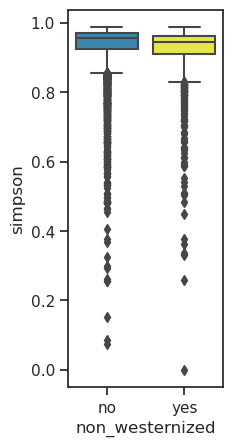

In [42]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [2,5]
my_pal = {"yes": "#ffff33", "no": "#2b8cbe"}
sns.boxplot(x="non_westernized", y="simpson", data=sgb_richness, palette=my_pal)
print(scipy.stats.mannwhitneyu(sgb_richness.loc[sgb_richness['non_westernized']=='yes']['simpson'], sgb_richness.loc[sgb_richness['non_westernized']=='no']['simpson'], alternative='two-sided'))
# plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/simpson.svg')

In [94]:
adults_prevalences = adults_abundances.copy()
adults_prevalences[adults_prevalences > 0] = 1
adults_prevalences

,Prevotella copri clade A (SGB1626),Ruminococcus sp NSJ 71 (SGB4290),Coprococcus eutactus (SGB5117),GGB3226 SGB4260 (SGB4260),Ruminococcaceae unclassified SGB15234 (SGB15234),Phocaeicola vulgatus (SGB1814),Alistipes putredinis (SGB2318),Dialister invisus (SGB5825_group),Faecalibacterium prausnitzii (SGB15332_group),Bacilli unclassified SGB6571 (SGB6571),...,Aquamicrobium defluvii (SGB32233),Jeotgalibaca porci (SGB64172),Paracoccus solventivorans (SGB10725),Paracandidimonas soli (SGB32666),Paracoccus alkenifer (SGB10726),Arcobacter trophiarum (SGB28493),Aquamicrobium lusatiense (SGB89540),Proteiniborus ethanoligenes (SGB8530),Propioniciclava sp MC1595 (SGB87720),Bosea sp WAO (SGB11414)
O2_UC49_0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC49_2,0.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC50_0,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC50_2,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
O2_UC51_0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
C16-20627-TZ,1.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C16-20645-TZ,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C16-20646-TZ,1.0,1.0,1.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
C16-20647-TZ,1.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [95]:
uSGBs = [x for x in adults_prevalences.columns.tolist() if 'SGB' in x.split(' (')[0]]
kSGBs = [x for x in adults_prevalences.columns.tolist() if 'SGB' not in x.split(' (')[0]]

In [96]:
sgb_richness = adults_prevalences[uSGBs].sum(axis=1)
sgb_richness = pd.DataFrame(sgb_richness)
sgb_richness.columns = ['richness']
sgb_richness['SGB type'] = 'uSGBs'
sgb_richness['non_westernized'] = adults_metadata.loc[sgb_richness.index,'non_westernized']
sgb_richness
print(scipy.stats.mannwhitneyu(sgb_richness.loc[sgb_richness['non_westernized']=='yes']['richness'], sgb_richness.loc[sgb_richness['non_westernized']=='no']['richness'], alternative='two-sided'))


MannwhitneyuResult(statistic=4857744.0, pvalue=1.5175868182799762e-121)


In [97]:
ksgb_richness = adults_prevalences[kSGBs].sum(axis=1)
ksgb_richness = pd.DataFrame(ksgb_richness)
ksgb_richness.columns = ['richness']
ksgb_richness['SGB type'] = 'kSGBs'
ksgb_richness['non_westernized'] = adults_metadata.loc[ksgb_richness.index,'non_westernized']
sgb_richness = ksgb_richness.append(sgb_richness)
sgb_richness
print(scipy.stats.mannwhitneyu(ksgb_richness.loc[ksgb_richness['non_westernized']=='yes']['richness'], ksgb_richness.loc[ksgb_richness['non_westernized']=='no']['richness'], alternative='two-sided'))


MannwhitneyuResult(statistic=3632496.0, pvalue=0.00015377544332842674)


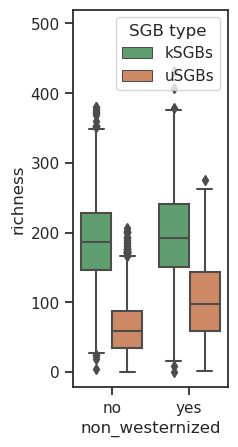

In [98]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [2,5]
my_pal = {"kSGBs": "#55a868", "uSGBs": "#dd8452"}
plot = sns.boxplot(x="non_westernized", y="richness", hue='SGB type', data=sgb_richness, palette=my_pal)
plot.set(ylim=(None, 520))
#print(scipy.stats.mannwhitneyu(sgb_richness.loc[sgb_richness['non_westernized']=='yes']['richness'], sgb_richness.loc[sgb_richness['non_westernized']=='no']['richness'], alternative='two-sided'))
plt.pyplot.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/richness.svg')

In [99]:
sgb_richness = adults_prevalences[uSGBs].sum(axis=1)
sgb_richness = pd.DataFrame(sgb_richness)
sgb_richness.columns = ['richness']
sgb_richness['SGB type'] = 'uSGBs'
sgb_richness['non_westernized'] = adults_metadata.loc[sgb_richness.index,'non_westernized']
sgb_richness['number_reads'] = adults_metadata.loc[sgb_richness.index,'number_reads']
res_1 = smf.ols(formula='richness ~ non_westernized + number_reads', data=sgb_richness).fit()
res_2 = smf.ols(formula='richness ~ number_reads', data=sgb_richness).fit()

result = sm.stats.anova_lm(res_2, res_1, test='Chisq')
p_anova = result['Pr(>Chisq)'][1]
p_lm = res_1.pvalues[1]

print('{} {} {} {}'.format(res_1.rsquared, res_2.rsquared, p_anova, p_lm))

0.15366473280247073 0.037284871241978323 0.0 3.72608863798154e-194


In [105]:
sgb_richness = adults_prevalences[kSGBs].sum(axis=1)
sgb_richness = pd.DataFrame(sgb_richness)
sgb_richness.columns = ['richness']
sgb_richness['SGB type'] = 'kSGBs'
sgb_richness['non_westernized'] = adults_metadata.loc[sgb_richness.index,'non_westernized']
sgb_richness['number_reads'] = adults_metadata.loc[sgb_richness.index,'number_reads']
res_1 = smf.ols(formula='richness ~ non_westernized + number_reads', data=sgb_richness).fit()
res_2 = smf.ols(formula='richness ~ number_reads', data=sgb_richness).fit()

result = sm.stats.anova_lm(res_2, res_1, test='Chisq')
p_anova = result['Pr(>Chisq)'][1]
p_lm = res_1.pvalues[1]

print('{} {} {} {}'.format(res_1.rsquared, res_2.rsquared, p_anova, p_lm))

0.1261916802651628 0.12568677211398727 0.0 0.04655802501089875
